# 🔍 Vector Indexing Techniques: A Deep Dive
## FLAT · IVFFlat · HNSW — Performance, Tradeoffs & Bottlenecks

---

> **Goal:** Understand how different Approximate Nearest Neighbor (ANN) indexing strategies behave across dimensions of **speed**, **recall**, **memory**, and **build time** — using only open-source tools.

### 🧰 Stack Used
| Component | Library |
|---|---|
| Embeddings | `sentence-transformers` (all-MiniLM-L6-v2) |
| Vector DB / Indexing | `faiss-cpu` |
| Benchmarking | `numpy`, `time`, `tracemalloc` |
| Visualization | `matplotlib`, `seaborn` |

### 📖 What You'll Learn
1. How **FLAT** (brute-force exact search) works and when to use it
2. How **IVFFlat** clusters vectors to speed up search (and what you trade away)
3. How **HNSW** builds a navigable small-world graph for ultra-fast search
4. How to measure **recall@k**, **QPS**, **build time**, and **memory footprint**
5. Practical guidance on **parameter tuning** (`nlist`, `nprobe`, `M`, `efSearch`)

---

## 📦 Cell 1 — Install Dependencies

Run this once. Restart kernel after installation if needed.

In [4]:
#!pip3 install faiss-cpu sentence-transformers numpy matplotlib seaborn pandas tqdm

---
## ⚙️ Cell 2 — CONFIGURATION (Edit This!)

Set your data folder path and experiment parameters here.

**Supported file types:** `.txt`, `.csv` (text column), `.json` (list of strings or `{"text": ...}` objects).

If `DATA_FOLDER = None`, a synthetic dataset will be auto-generated for you.

In [21]:
# ============================================================
#   ✏️  CONFIGURATION — Edit values below
# ============================================================

# Path to your folder containing text files (set None to use synthetic data)
DATA_FOLDER = r"D:\Harsh\Coding\2026 AI\04-GenAI\docs"          # e.g.  "/home/user/my_documents"

# Number of documents to load/generate (ignored if loading real files)
SYNTHETIC_N = 5000          # Try 1000 → 50000 to see scaling effects

# Embedding model (any sentence-transformers model works)
EMBEDDING_MODEL = "all-MiniLM-L6-v2"   # fast & small; swap to "all-mpnet-base-v2" for better quality

# Batch size for encoding (lower if you hit OOM)
ENCODE_BATCH_SIZE = 128

# Number of query vectors to use in benchmark
N_QUERIES = 200

# k — how many nearest neighbors to retrieve
TOP_K = 10

# ---- IVFFlat params ----
IVFFLAT_NLIST   = 100       # Number of Voronoi cells (clusters). Rule of thumb: sqrt(N)
IVFFLAT_NPROBE  = 10        # Cells to search at query time (higher = more recall, slower)

# ---- HNSW params ----
HNSW_M          = 32        # Connections per node per layer (higher = better recall, more RAM)
HNSW_EF_CONSTRUCTION = 200  # Build-time search width (higher = better index quality, slower build)
HNSW_EF_SEARCH  = 64        # Query-time search width (higher = better recall, slower query)

# Recall sweep — nprobe values to test for IVFFlat recall/speed curve
IVFFLAT_NPROBE_SWEEP = [1, 5, 10, 20, 50, 100]

# Recall sweep — efSearch values to test for HNSW recall/speed curve
HNSW_EF_SWEEP        = [16, 32, 64, 128, 256]

# Random seed
SEED = 42

print("✅ Configuration loaded.")
print(f"   Data source  : {'Synthetic (' + str(SYNTHETIC_N) + ' docs)' if DATA_FOLDER is None else DATA_FOLDER}")
print(f"   Embed model  : {EMBEDDING_MODEL}")
print(f"   Top-K        : {TOP_K}")
print(f"   IVFFlat nlist: {IVFFLAT_NLIST}, nprobe: {IVFFLAT_NPROBE}")
print(f"   HNSW M       : {HNSW_M}, efSearch: {HNSW_EF_SEARCH}")

✅ Configuration loaded.
   Data source  : D:\Harsh\Coding\2026 AI\04-GenAI\docs
   Embed model  : all-MiniLM-L6-v2
   Top-K        : 10
   IVFFlat nlist: 100, nprobe: 10
   HNSW M       : 32, efSearch: 64


---
## 📚 Cell 3 — Imports & Helpers

In [22]:
import os, time, glob, json, tracemalloc
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

np.random.seed(SEED)

# ---- Colour palette ----
PALETTE = {"FLAT": "#2196F3", "IVFFlat": "#FF9800", "HNSW": "#4CAF50"}
sns.set_theme(style="whitegrid", font_scale=1.1)

# ---- Utility: measure memory of a callable ----
def measure_memory_mb(fn):
    tracemalloc.start()
    fn()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024 / 1024  # MB

# ---- Utility: time a callable, return (result, elapsed_seconds) ----
def timeit(fn):
    t0 = time.perf_counter()
    result = fn()
    return result, time.perf_counter() - t0

print(f"✅ FAISS version : {faiss.__version__}")
print(f"   NumPy version : {np.__version__}")

✅ FAISS version : 1.7.4
   NumPy version : 1.26.4


---
## 📂 Cell 4 — Load or Generate Data

Loads text from your configured folder, or generates synthetic sentences if `DATA_FOLDER = None`.

In [25]:
# ============================================================
# Cell 4 — Load or Generate Data  (with PDF support + chunking)
# ============================================================

# ✏️  Extra config knobs for chunking (can also go in Cell 2)
CHUNK_SIZE        = 400    # Target words per chunk
CHUNK_OVERLAP     = 100    # Words shared between consecutive chunks
MIN_CHUNK_WORDS   = 30     # Discard chunks shorter than this (headers, noise)

# ──────────────────────────────────────────────────────────────
# Helpers
# ──────────────────────────────────────────────────────────────

def chunk_text(text, chunk_size=CHUNK_SIZE,
               overlap=CHUNK_OVERLAP, min_words=MIN_CHUNK_WORDS):
    """
    Sliding-window word-level chunker.

    Why word-level (not character)?  Embedding models have a *token*
    budget (~256–512 tokens).  Words are a close-enough proxy and much
    cheaper to compute than running a real tokenizer.

    Overlap keeps context across chunk boundaries so a sentence that
    straddles two chunks isn't lost in either.
    """
    words  = text.split()
    chunks = []
    start  = 0
    while start < len(words):
        end   = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end]).strip()
        if len(chunk.split()) >= min_words:
            chunks.append(chunk)
        if end == len(words):
            break
        start += chunk_size - overlap          # slide forward with overlap
    return chunks


def extract_text_from_pdf(fpath):
    """
    Extract text from a PDF page-by-page using pdfplumber.
    Falls back to pypdf on failure.
    Returns a list of (page_num, page_text) tuples.
    """
    pages = []
    try:
        import pdfplumber
        with pdfplumber.open(fpath) as pdf:
            for i, page in enumerate(pdf.pages, 1):
                text = page.extract_text() or ""
                if text.strip():
                    pages.append((i, text))
        if pages:
            return pages
    except Exception:
        pass

    # pypdf fallback
    try:
        from pypdf import PdfReader
        reader = PdfReader(fpath)
        for i, page in enumerate(reader.pages, 1):
            text = page.extract_text() or ""
            if text.strip():
                pages.append((i, text))
    except Exception as e:
        print(f"   ⚠️  Could not read PDF {fpath}: {e}")
    return pages


def load_texts_from_folder(folder):
    """
    Recursively load text from .txt / .csv / .json / .pdf files.
    Returns list of raw text strings (pre-chunking).
    """
    raw_texts = []
    pdf_count = txt_count = csv_count = json_count = 0

    for fpath in glob.glob(os.path.join(folder, "**", "*"), recursive=True):
        if not os.path.isfile(fpath):
            continue
        ext = os.path.splitext(fpath)[1].lower()

        try:
            # ── PDF ──────────────────────────────────────────────────
            if ext == ".pdf":
                pages = extract_text_from_pdf(fpath)
                if pages:
                    # Join page texts; we chunk the whole doc below
                    full_text = "\n\n".join(page_text for _, page_text in pages)
                    raw_texts.append(full_text)
                    pdf_count += 1
                else:
                    print(f"   ⚠️  PDF appears to be scanned/image-only: {os.path.basename(fpath)}")

            # ── Plain text ───────────────────────────────────────────
            elif ext == ".txt":
                with open(fpath, encoding="utf-8", errors="ignore") as f:
                    raw_texts.append(f.read())
                txt_count += 1

            # ── CSV ──────────────────────────────────────────────────
            elif ext == ".csv":
                df  = pd.read_csv(fpath, on_bad_lines="skip")
                col = next((c for c in df.columns if "text" in c.lower()), df.columns[0])
                combined = " ".join(df[col].dropna().astype(str).tolist())
                raw_texts.append(combined)
                csv_count += 1

            # ── JSON ─────────────────────────────────────────────────
            elif ext == ".json":
                with open(fpath, encoding="utf-8", errors="ignore") as f:
                    data = json.load(f)
                if isinstance(data, list):
                    for item in data:
                        if isinstance(item, str):
                            raw_texts.append(item)
                        elif isinstance(item, dict):
                            v = item.get("text") or item.get("content") or \
                                str(list(item.values())[0])
                            raw_texts.append(v)
                elif isinstance(data, dict):
                    raw_texts.append(str(data))
                json_count += 1

        except Exception as e:
            print(f"   ⚠️  Skipping {os.path.basename(fpath)}: {e}")

    print(f"   Files read → PDF:{pdf_count}  TXT:{txt_count}  "
          f"CSV:{csv_count}  JSON:{json_count}")
    return raw_texts


def apply_chunking(raw_texts, source_label="doc"):
    """
    Apply sliding-window chunker to every raw text.
    Returns (chunks_list, metadata_list).
    metadata carries the source index so you can trace a chunk back.
    """
    chunks, meta = [], []
    for doc_id, text in enumerate(tqdm(raw_texts, desc="Chunking")):
        doc_chunks = chunk_text(text)
        for ci, ch in enumerate(doc_chunks):
            chunks.append(ch)
            meta.append({"doc_id": doc_id, "chunk_id": ci,
                         "source": f"{source_label}_{doc_id}"})
    return chunks, meta


def generate_synthetic_texts(n):
    topics = ["machine learning", "deep learning", "natural language processing",
              "computer vision", "reinforcement learning", "data science",
              "neural networks", "transformers", "embeddings", "vector search"]
    verbs  = ["enables", "improves", "transforms", "accelerates", "simplifies",
              "advances", "revolutionizes", "enhances", "supports", "powers"]
    objs   = ["real-world applications", "research workflows", "production systems",
              "model performance", "data pipelines", "search quality",
              "user experiences", "scientific discovery", "automation", "decision making"]
    rng    = np.random.default_rng(SEED)
    return [
        f"{rng.choice(topics).capitalize()} {rng.choice(verbs)} {rng.choice(objs)}. (doc #{i})"
        for i in range(n)
    ]


# ──────────────────────────────────────────────────────────────
# Main loading logic
# ──────────────────────────────────────────────────────────────

if DATA_FOLDER is not None:
    print(f"📂 Loading from: {DATA_FOLDER}")
    raw_texts = load_texts_from_folder(DATA_FOLDER)
    if not raw_texts:
        raise ValueError("No texts found! Check the folder path and file types.")

    print(f"\n✂️  Chunking  (size={CHUNK_SIZE} words, overlap={CHUNK_OVERLAP} words)...")
    all_texts, chunk_meta = apply_chunking(raw_texts, source_label="file")

else:
    print(f"🤖 Generating {SYNTHETIC_N} synthetic sentences...")
    # Synthetic sentences are already short — wrap each in a list,
    # chunker will keep them as-is (no splitting needed).
    raw_texts  = generate_synthetic_texts(SYNTHETIC_N)
    all_texts  = raw_texts                        # no chunking needed
    chunk_meta = [{"doc_id": i, "chunk_id": 0, "source": f"synthetic_{i}"}
                  for i in range(len(raw_texts))]

# ──────────────────────────────────────────────────────────────
# Summary
# ──────────────────────────────────────────────────────────────

word_counts = [len(t.split()) for t in all_texts]

print(f"\n✅ Final corpus stats")
print(f"   Total chunks     : {len(all_texts):,}")
print(f"   Words / chunk    : min={min(word_counts)}  "
      f"mean={int(np.mean(word_counts))}  max={max(word_counts)}")
print(f"   Chunking params  : size={CHUNK_SIZE} words  overlap={CHUNK_OVERLAP} words")

print("\nSample chunks:")
for i, t in enumerate(all_texts[:3]):
    preview = t[:120].replace("\n", " ")
    print(f"  [{chunk_meta[i]['source']} / chunk {chunk_meta[i]['chunk_id']}] {preview}…")

📂 Loading from: D:\Harsh\Coding\2026 AI\04-GenAI\docs
   Files read → PDF:1  TXT:0  CSV:0  JSON:0

✂️  Chunking  (size=400 words, overlap=100 words)...


Chunking:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Final corpus stats
   Total chunks     : 538
   Words / chunk    : min=301  mean=399  max=400
   Chunking params  : size=400 words  overlap=100 words

Sample chunks:
  [file_0 / chunk 0] Springer Texts in Statistics An Introduction to Statistical LearningGareth James Daniela Witten Trevor Hastie Robert Tib…
  [file_0 / chunk 1] etc. in this publi- cation does not imply, even in the absence of a speciﬁc statement, that such names are exempt from t…
  [file_0 / chunk 2] ﬁelds. One of the reasons for ESL’s popularity is its relatively accessible style. But ESL is intended for individuals w…


---
## 🧠 Cell 5 — Generate Embeddings

We use **`sentence-transformers`** to convert text → dense float32 vectors.

> 💡 `all-MiniLM-L6-v2` outputs **384-dimensional** vectors. FAISS will work with whatever dimension your model produces.

In [26]:
print(f"⏳ Loading embedding model: {EMBEDDING_MODEL}")
model = SentenceTransformer(EMBEDDING_MODEL)

print(f"⏳ Encoding {len(all_texts):,} documents (batch_size={ENCODE_BATCH_SIZE})...")
t0 = time.perf_counter()
all_embeddings = model.encode(
    all_texts,
    batch_size=ENCODE_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # L2-normalize → cosine sim = dot product
)
encode_time = time.perf_counter() - t0

# Ensure float32 for FAISS
all_embeddings = all_embeddings.astype(np.float32)

DIM = all_embeddings.shape[1]
N   = all_embeddings.shape[0]

print(f"\n✅ Embedding matrix shape : {all_embeddings.shape}")
print(f"   Dimension (D)          : {DIM}")
print(f"   Num vectors (N)        : {N:,}")
print(f"   Encode time            : {encode_time:.1f}s  ({N/encode_time:.0f} docs/sec)")
print(f"   Memory (approx)        : {all_embeddings.nbytes / 1024**2:.1f} MB")

# Hold out query vectors (never added to index)
query_idx = np.random.choice(N, N_QUERIES, replace=False)
query_vectors = all_embeddings[query_idx].copy()

# Corpus = all vectors (queries are also in corpus to enable recall measurement)
corpus_vectors = all_embeddings.copy()

print(f"\n🔍 Using {N_QUERIES} query vectors for benchmarking")

⏳ Loading embedding model: all-MiniLM-L6-v2
⏳ Encoding 538 documents (batch_size=128)...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]


✅ Embedding matrix shape : (538, 384)
   Dimension (D)          : 384
   Num vectors (N)        : 538
   Encode time            : 9.5s  (56 docs/sec)
   Memory (approx)        : 0.8 MB

🔍 Using 200 query vectors for benchmarking


---
## 📖 Cell 6 — Theory: How Each Index Works

### 1. FLAT (Brute-Force Exact Search)

```
Query ──► Compare against ALL N vectors ──► Return top-k
```

- **Recall**: Always **100%** — it checks every vector, no approximation.
- **Build time**: Instant — no structure is built, vectors are just stored contiguously.
- **Query time**: O(N·D) — scales linearly with corpus size. Slow for large N.
- **Memory**: Minimal — just the raw float32 matrix.
- **Use when**: N < ~100K, or when you need ground-truth recall to benchmark other indexes.

---

### 2. IVFFlat (Inverted File Index)

```
Build: K-means → nlist cluster centroids
       Each vector assigned to its nearest centroid

Query: Find the nprobe closest centroids
       Search only vectors in those nprobe clusters
       Return top-k from that subset
```

- **Recall**: < 100% (approximate). Controlled by `nprobe`: higher → more recall, slower.
- **Build time**: Dominated by K-means training. Moderate.
- **Query time**: O(nprobe · N/nlist · D) — much faster than FLAT for large N.
- **Memory**: Similar to FLAT (stores vectors), plus small centroid table.
- **Key params**: `nlist` (# clusters), `nprobe` (# clusters searched at query time).
- **Use when**: Large N, moderate latency budget, don't need extreme recall.

---

### 3. HNSW (Hierarchical Navigable Small World)

```
Build: Multi-layer graph where each node connects to M nearest neighbors
       Upper layers = coarse navigation; lower layers = fine-grained search

Query: Start at top layer, greedily navigate toward query
       Descend layers, expanding search width (efSearch)
       Return top-k from layer 0
```

- **Recall**: Very high (tunable via `efSearch`). Often 95–99%+ at good speed.
- **Build time**: Slowest — building the graph is expensive, especially for high M.
- **Query time**: O(log N) — extremely fast even for very large N.
- **Memory**: High — each vector stores M graph links per layer.
- **Key params**: `M` (graph connectivity), `efConstruction` (build quality), `efSearch` (query quality).
- **Use when**: Low latency is critical, large N, willing to spend RAM & build time.

---

### Quick Comparison Table

| | FLAT | IVFFlat | HNSW |
|---|---|---|---|
| **Recall** | 100% (exact) | ~80–99% | ~90–99% |
| **Build time** | ⚡ Instant | 🔶 Moderate | 🔴 Slow |
| **Query speed** | 🔴 Slow (O(N)) | 🔶 Moderate | ⚡ Fast (O(log N)) |
| **Memory** | ✅ Low | ✅ Low | 🔶 High |
| **Tunable recall** | ❌ No | ✅ nprobe | ✅ efSearch |
| **Best for** | Small N / ground truth | Large N, RAM constrained | Large N, latency critical |

---
## 🏗️ Cell 7 — Build All Three Indexes

In [27]:
results = {}  # Will hold all benchmark metrics

# ── FLAT ──────────────────────────────────────────────────────────────
print("🔨 Building FLAT index...")
def build_flat():
    idx = faiss.IndexFlatIP(DIM)   # Inner Product (= cosine sim for L2-normalized vecs)
    idx.add(corpus_vectors)
    return idx

t0 = time.perf_counter()
index_flat = build_flat()
build_time_flat = time.perf_counter() - t0
print(f"   ✅ FLAT built in {build_time_flat:.3f}s  |  ntotal={index_flat.ntotal:,}")


# ── IVFFlat ───────────────────────────────────────────────────────────
print("\n🔨 Building IVFFlat index...")
def build_ivfflat():
    quantizer = faiss.IndexFlatIP(DIM)          # Coarse quantizer
    idx = faiss.IndexIVFFlat(quantizer, DIM,
                              IVFFLAT_NLIST,
                              faiss.METRIC_INNER_PRODUCT)
    idx.train(corpus_vectors)                    # K-means clustering
    idx.add(corpus_vectors)
    idx.nprobe = IVFFLAT_NPROBE
    return idx

t0 = time.perf_counter()
index_ivf = build_ivfflat()
build_time_ivf = time.perf_counter() - t0
print(f"   ✅ IVFFlat built in {build_time_ivf:.3f}s  |  ntotal={index_ivf.ntotal:,}  nlist={IVFFLAT_NLIST}")


# ── HNSW ──────────────────────────────────────────────────────────────
print("\n🔨 Building HNSW index...")
def build_hnsw():
    idx = faiss.IndexHNSWFlat(DIM, HNSW_M, faiss.METRIC_INNER_PRODUCT)
    idx.hnsw.efConstruction = HNSW_EF_CONSTRUCTION
    idx.add(corpus_vectors)
    idx.hnsw.efSearch = HNSW_EF_SEARCH
    return idx

t0 = time.perf_counter()
index_hnsw = build_hnsw()
build_time_hnsw = time.perf_counter() - t0
print(f"   ✅ HNSW built in {build_time_hnsw:.3f}s  |  ntotal={index_hnsw.ntotal:,}  M={HNSW_M}")


# Summary
print("\n" + "─"*50)
print(f"{'Index':<12} {'Build Time':>12}")
print("─"*50)
for name, bt in [("FLAT", build_time_flat), ("IVFFlat", build_time_ivf), ("HNSW", build_time_hnsw)]:
    print(f"{name:<12} {bt:>11.3f}s")

🔨 Building FLAT index...
   ✅ FLAT built in 0.001s  |  ntotal=538

🔨 Building IVFFlat index...
   ✅ IVFFlat built in 0.011s  |  ntotal=538  nlist=100

🔨 Building HNSW index...
   ✅ HNSW built in 0.021s  |  ntotal=538  M=32

──────────────────────────────────────────────────
Index          Build Time
──────────────────────────────────────────────────
FLAT               0.001s
IVFFlat            0.011s
HNSW               0.021s


---
## 🏎️ Cell 8 — Query Speed Benchmark (QPS)

We run all `N_QUERIES` queries through each index and compute **Queries Per Second (QPS)**.

In [28]:
def run_queries(index, qvecs, k):
    """Run batch queries, return (distances, indices, elapsed_sec)"""
    t0 = time.perf_counter()
    D, I = index.search(qvecs, k)
    elapsed = time.perf_counter() - t0
    return D, I, elapsed


# Warm-up run (JIT / cache warm-up)
for idx in [index_flat, index_ivf, index_hnsw]:
    idx.search(query_vectors[:5], TOP_K)

# Benchmark
print(f"⏱️  Running {N_QUERIES} queries with k={TOP_K}...\n")

_, flat_I, flat_time = run_queries(index_flat, query_vectors, TOP_K)
_, ivf_I,  ivf_time  = run_queries(index_ivf,  query_vectors, TOP_K)
_, hnsw_I, hnsw_time = run_queries(index_hnsw, query_vectors, TOP_K)

flat_qps = N_QUERIES / flat_time
ivf_qps  = N_QUERIES / ivf_time
hnsw_qps = N_QUERIES / hnsw_time

print(f"{'Index':<12} {'Total Time':>12} {'QPS':>10} {'ms/query':>10}")
print("─"*48)
for name, t, qps in [("FLAT", flat_time, flat_qps),
                      ("IVFFlat", ivf_time, ivf_qps),
                      ("HNSW", hnsw_time, hnsw_qps)]:
    print(f"{name:<12} {t:>11.3f}s {qps:>10.1f} {1000/qps:>9.2f}ms")

results['build_times'] = {"FLAT": build_time_flat, "IVFFlat": build_time_ivf, "HNSW": build_time_hnsw}
results['qps']         = {"FLAT": flat_qps,        "IVFFlat": ivf_qps,        "HNSW": hnsw_qps}

⏱️  Running 200 queries with k=10...

Index          Total Time        QPS   ms/query
────────────────────────────────────────────────
FLAT               0.001s   173115.2      0.01ms
IVFFlat            0.001s   327654.0      0.00ms
HNSW               0.001s   163332.0      0.01ms


---
## 🎯 Cell 9 — Recall@K Measurement

**Recall@K** = fraction of true top-K neighbors that appear in the retrieved top-K results.

FLAT is our **ground truth** (exact search). We compare IVFFlat and HNSW against it.

In [29]:
def recall_at_k(true_I, approx_I):
    """Compute mean recall@k over all queries."""
    recalls = []
    for gt_row, approx_row in zip(true_I, approx_I):
        gt_set  = set(gt_row.tolist())
        ap_set  = set(approx_row.tolist())
        recall  = len(gt_set & ap_set) / len(gt_set) if gt_set else 0.0
        recalls.append(recall)
    return float(np.mean(recalls))


recall_ivf  = recall_at_k(flat_I, ivf_I)
recall_hnsw = recall_at_k(flat_I, hnsw_I)

print(f"🎯 Recall@{TOP_K} Results")
print(f"   FLAT    (ground truth) : 1.0000  (exact)")
print(f"   IVFFlat (nprobe={IVFFLAT_NPROBE:<3})   : {recall_ivf:.4f}")
print(f"   HNSW    (efSearch={HNSW_EF_SEARCH:<3}) : {recall_hnsw:.4f}")

results['recall'] = {"FLAT": 1.0, "IVFFlat": recall_ivf, "HNSW": recall_hnsw}

🎯 Recall@10 Results
   FLAT    (ground truth) : 1.0000  (exact)
   IVFFlat (nprobe=10 )   : 0.9460
   HNSW    (efSearch=64 ) : 0.9300


---
## 💾 Cell 10 — Memory Usage

We measure the peak memory allocated during index construction for each strategy.

In [30]:
print("💾 Measuring peak memory during index construction...")

mem_flat = measure_memory_mb(build_flat)
mem_ivf  = measure_memory_mb(build_ivfflat)
mem_hnsw = measure_memory_mb(build_hnsw)

raw_matrix_mb = corpus_vectors.nbytes / 1024**2

print(f"\n   Raw float32 matrix               : {raw_matrix_mb:.1f} MB")
print(f"   FLAT peak memory                 : {mem_flat:.1f} MB  (overhead: {mem_flat - raw_matrix_mb:+.1f} MB)")
print(f"   IVFFlat peak memory              : {mem_ivf:.1f} MB  (overhead: {mem_ivf - raw_matrix_mb:+.1f} MB)")
print(f"   HNSW peak memory                 : {mem_hnsw:.1f} MB  (overhead: {mem_hnsw - raw_matrix_mb:+.1f} MB)")
print(f"\n   ℹ️  HNSW overhead = graph links ({HNSW_M} connections × layers × 4 bytes each)")

results['memory_mb'] = {"FLAT": mem_flat, "IVFFlat": mem_ivf, "HNSW": mem_hnsw}

💾 Measuring peak memory during index construction...

   Raw float32 matrix               : 0.8 MB
   FLAT peak memory                 : 0.1 MB  (overhead: -0.6 MB)
   IVFFlat peak memory              : 0.1 MB  (overhead: -0.6 MB)
   HNSW peak memory                 : 0.0 MB  (overhead: -0.8 MB)

   ℹ️  HNSW overhead = graph links (32 connections × layers × 4 bytes each)


---
## 📈 Cell 11 — IVFFlat: Recall vs Speed (nprobe sweep)

This is the most important tradeoff curve for IVFFlat: higher `nprobe` → better recall, but slower queries.

In [31]:
ivf_sweep_results = []
print(f"🔄 Sweeping IVFFlat nprobe: {IVFFLAT_NPROBE_SWEEP}\n")

for nprobe in tqdm(IVFFLAT_NPROBE_SWEEP, desc="nprobe"):
    index_ivf.nprobe = nprobe
    _, I_sweep, t_sweep = run_queries(index_ivf, query_vectors, TOP_K)
    rec = recall_at_k(flat_I, I_sweep)
    qps = N_QUERIES / t_sweep
    ivf_sweep_results.append({"nprobe": nprobe, "recall": rec, "qps": qps, "ms_per_query": 1000/qps})
    print(f"   nprobe={nprobe:<4}  recall={rec:.4f}  QPS={qps:>8.1f}  ms/q={1000/qps:.2f}")

df_ivf_sweep = pd.DataFrame(ivf_sweep_results)
results['ivf_sweep'] = df_ivf_sweep

# Reset to configured value
index_ivf.nprobe = IVFFLAT_NPROBE

🔄 Sweeping IVFFlat nprobe: [1, 5, 10, 20, 50, 100]



nprobe:   0%|          | 0/6 [00:00<?, ?it/s]

   nprobe=1     recall=0.4710  QPS=201775.6  ms/q=0.00
   nprobe=5     recall=0.8680  QPS=285103.3  ms/q=0.00
   nprobe=10    recall=0.9460  QPS=339270.6  ms/q=0.00
   nprobe=20    recall=0.9850  QPS=293556.4  ms/q=0.00
   nprobe=50    recall=0.9985  QPS=225402.9  ms/q=0.00
   nprobe=100   recall=1.0000  QPS=162403.6  ms/q=0.01


---
## 📈 Cell 12 — HNSW: Recall vs Speed (efSearch sweep)

Similar sweep for HNSW's `efSearch` parameter.

In [32]:
hnsw_sweep_results = []
print(f"🔄 Sweeping HNSW efSearch: {HNSW_EF_SWEEP}\n")

for ef in tqdm(HNSW_EF_SWEEP, desc="efSearch"):
    index_hnsw.hnsw.efSearch = ef
    _, I_sweep, t_sweep = run_queries(index_hnsw, query_vectors, TOP_K)
    rec = recall_at_k(flat_I, I_sweep)
    qps = N_QUERIES / t_sweep
    hnsw_sweep_results.append({"efSearch": ef, "recall": rec, "qps": qps, "ms_per_query": 1000/qps})
    print(f"   efSearch={ef:<5}  recall={rec:.4f}  QPS={qps:>8.1f}  ms/q={1000/qps:.2f}")

df_hnsw_sweep = pd.DataFrame(hnsw_sweep_results)
results['hnsw_sweep'] = df_hnsw_sweep

# Reset to configured value
index_hnsw.hnsw.efSearch = HNSW_EF_SEARCH

🔄 Sweeping HNSW efSearch: [16, 32, 64, 128, 256]



efSearch:   0%|          | 0/5 [00:00<?, ?it/s]

   efSearch=16     recall=0.9260  QPS= 46356.4  ms/q=0.02
   efSearch=32     recall=0.9295  QPS= 69952.1  ms/q=0.01
   efSearch=64     recall=0.9300  QPS= 39928.9  ms/q=0.03
   efSearch=128    recall=0.9300  QPS= 77041.6  ms/q=0.01
   efSearch=256    recall=0.9300  QPS= 52633.0  ms/q=0.02


---
## 📊 Cell 13 — Full Visualization Dashboard

All benchmark results in one plot.

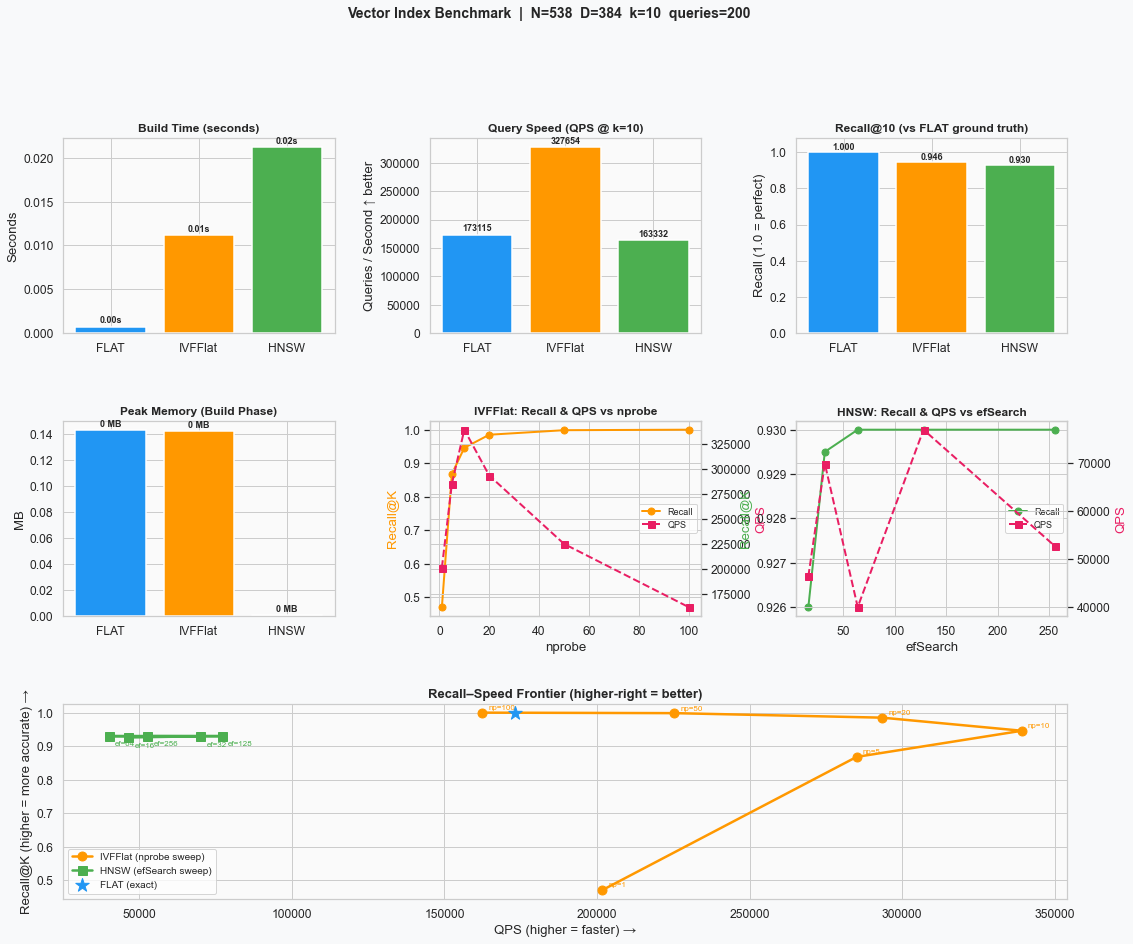

✅ Plot saved as index_benchmark.png


In [33]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

names  = ["FLAT", "IVFFlat", "HNSW"]
colors = [PALETTE[n] for n in names]

# ── 1. Build Times ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bt_vals = [results['build_times'][n] for n in names]
bars = ax1.bar(names, bt_vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, bt_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(bt_vals)*0.01,
             f"{val:.2f}s", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Build Time (seconds)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Seconds')
ax1.set_facecolor('#FAFAFA')

# ── 2. QPS ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
qps_vals = [results['qps'][n] for n in names]
bars = ax2.bar(names, qps_vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, qps_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(qps_vals)*0.01,
             f"{val:.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title(f'Query Speed (QPS @ k={TOP_K})', fontweight='bold', fontsize=12)
ax2.set_ylabel('Queries / Second ↑ better')
ax2.set_facecolor('#FAFAFA')

# ── 3. Recall@K ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
rec_vals = [results['recall'][n] for n in names]
bars = ax3.bar(names, rec_vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, rec_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_title(f'Recall@{TOP_K} (vs FLAT ground truth)', fontweight='bold', fontsize=12)
ax3.set_ylabel('Recall (1.0 = perfect)')
ax3.set_ylim(0, 1.08)
ax3.set_facecolor('#FAFAFA')

# ── 4. Memory Usage ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
mem_vals = [results['memory_mb'][n] for n in names]
bars = ax4.bar(names, mem_vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, mem_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mem_vals)*0.01,
             f"{val:.0f} MB", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_title('Peak Memory (Build Phase)', fontweight='bold', fontsize=12)
ax4.set_ylabel('MB')
ax4.set_facecolor('#FAFAFA')

# ── 5. IVFFlat: Recall vs nprobe ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5b = ax5.twinx()
ax5.plot(df_ivf_sweep['nprobe'], df_ivf_sweep['recall'], 'o-',
         color=PALETTE['IVFFlat'], lw=2, ms=7, label='Recall')
ax5b.plot(df_ivf_sweep['nprobe'], df_ivf_sweep['qps'], 's--',
          color='#E91E63', lw=2, ms=7, label='QPS')
ax5.set_title('IVFFlat: Recall & QPS vs nprobe', fontweight='bold', fontsize=12)
ax5.set_xlabel('nprobe')
ax5.set_ylabel('Recall@K', color=PALETTE['IVFFlat'])
ax5b.set_ylabel('QPS', color='#E91E63')
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
ax5.legend(lines1+lines2, labels1+labels2, loc='center right', fontsize=9)
ax5.set_facecolor('#FAFAFA')

# ── 6. HNSW: Recall vs efSearch ──────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6b = ax6.twinx()
ax6.plot(df_hnsw_sweep['efSearch'], df_hnsw_sweep['recall'], 'o-',
         color=PALETTE['HNSW'], lw=2, ms=7, label='Recall')
ax6b.plot(df_hnsw_sweep['efSearch'], df_hnsw_sweep['qps'], 's--',
          color='#E91E63', lw=2, ms=7, label='QPS')
ax6.set_title('HNSW: Recall & QPS vs efSearch', fontweight='bold', fontsize=12)
ax6.set_xlabel('efSearch')
ax6.set_ylabel('Recall@K', color=PALETTE['HNSW'])
ax6b.set_ylabel('QPS', color='#E91E63')
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1+lines2, labels1+labels2, loc='center right', fontsize=9)
ax6.set_facecolor('#FAFAFA')

# ── 7. Recall–Speed Frontier (combined) ──────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
# IVFFlat curve
ax7.plot(df_ivf_sweep['qps'], df_ivf_sweep['recall'], 'o-',
         color=PALETTE['IVFFlat'], lw=2.5, ms=9, label='IVFFlat (nprobe sweep)')
for _, row in df_ivf_sweep.iterrows():
    ax7.annotate(f"np={int(row.nprobe)}", (row.qps, row.recall),
                 xytext=(6, 3), textcoords='offset points', fontsize=8, color=PALETTE['IVFFlat'])
# HNSW curve
ax7.plot(df_hnsw_sweep['qps'], df_hnsw_sweep['recall'], 's-',
         color=PALETTE['HNSW'], lw=2.5, ms=9, label='HNSW (efSearch sweep)')
for _, row in df_hnsw_sweep.iterrows():
    ax7.annotate(f"ef={int(row.efSearch)}", (row.qps, row.recall),
                 xytext=(6, -10), textcoords='offset points', fontsize=8, color=PALETTE['HNSW'])
# FLAT point
ax7.scatter([results['qps']['FLAT']], [1.0], color=PALETTE['FLAT'], s=200, zorder=5,
            marker='*', label='FLAT (exact)')
ax7.set_title('Recall–Speed Frontier (higher-right = better)', fontweight='bold', fontsize=13)
ax7.set_xlabel('QPS (higher = faster) →')
ax7.set_ylabel('Recall@K (higher = more accurate) →')
ax7.legend(fontsize=10)
ax7.set_facecolor('#FAFAFA')

fig.suptitle(f'Vector Index Benchmark  |  N={N:,}  D={DIM}  k={TOP_K}  queries={N_QUERIES}',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('index_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as index_benchmark.png")

---
## 🔎 Cell 14 — Interactive Query: See Real Results

Pick a query text and see what each index returns. Compare the results side by side.

In [34]:
# ✏️ Change this to anything you want to search for!
QUERY_TEXT = "tell me about bayes theorem"

print(f"🔍 Query: \"{QUERY_TEXT}\"\n")
print(f"{'─'*70}")

q_vec = model.encode([QUERY_TEXT], normalize_embeddings=True).astype(np.float32)

for name, index in [("FLAT", index_flat), ("IVFFlat", index_ivf), ("HNSW", index_hnsw)]:
    D, I = index.search(q_vec, TOP_K)
    print(f"\n📌 {name}:")
    for rank, (doc_id, score) in enumerate(zip(I[0], D[0]), 1):
        text_preview = all_texts[doc_id][:90] if 0 <= doc_id < len(all_texts) else "[unknown]"
        print(f"   {rank:2}. [score={score:.4f}] {text_preview}")

🔍 Query: "tell me about bayes theorem"

──────────────────────────────────────────────────────────────────────

📌 FLAT:
    1. [score=0.4060] some values of x0. The Bayes error rate is analogous to the irreducible error, discussed e
    2. [score=0.3779] with predictor x0.Agoodclassiﬁer is one for which the test error ( 2.9) is smallest. The B
    3. [score=0.3741] will be assigned to the blue class. corresponds to predicting class one if Pr( Y=1|X=x0)>0
    4. [score=0.3641] the posterior probability output by the model corresponds to the probability that the mark
    5. [score=0.3369] i.e. there is only one feature. Suppose that we have Kclasses, and that if an observation 
    6. [score=0.3179] On the test set? (c) In general, as the sample size nincreases, do we expect the test pred
    7. [score=0.3145] Estimating the Regression Coeﬃcients ........ 1 3 3 4.3.3 Making Predictions .............
    8. [score=0.3119] 3 at all of the possible values for X1andX2, and have drawn in the 

---
## 📝 Cell 15 — Summary Report

Auto-generated interpretation of your benchmark results.

In [35]:
print("="*60)
print("         BENCHMARK SUMMARY REPORT")
print("="*60)
print(f"  Dataset   : {N:,} vectors  |  Dim={DIM}  |  k={TOP_K}")
print(f"  Queries   : {N_QUERIES}")
print("─"*60)

# Build times
print("\n📦 BUILD TIME")
bt = results['build_times']
print(f"  FLAT    : {bt['FLAT']:.3f}s   (no structure — just stores data)")
print(f"  IVFFlat : {bt['IVFFlat']:.3f}s  (K-means clustering nlist={IVFFLAT_NLIST})")
print(f"  HNSW    : {bt['HNSW']:.3f}s  (graph construction M={HNSW_M})")
fastest_build = min(bt, key=bt.get)
print(f"  → Fastest build: {fastest_build}")

# QPS
print("\n⚡ QUERY SPEED (QPS)")
qps = results['qps']
for n in names:
    print(f"  {n:<9}: {qps[n]:>8.1f} QPS  ({1000/qps[n]:.2f} ms/query)")
fastest_query = max(qps, key=qps.get)
speedup = qps[fastest_query] / qps['FLAT']
print(f"  → Fastest query: {fastest_query} ({speedup:.1f}x faster than FLAT)")

# Recall
print(f"\n🎯 RECALL@{TOP_K}")
rec = results['recall']
print(f"  FLAT    : {rec['FLAT']:.4f}  (exact — ground truth)")
print(f"  IVFFlat : {rec['IVFFlat']:.4f}  (nprobe={IVFFLAT_NPROBE})")
print(f"  HNSW    : {rec['HNSW']:.4f}  (efSearch={HNSW_EF_SEARCH})")

# Memory
print("\n💾 PEAK MEMORY (Build)")
mem = results['memory_mb']
for n in names:
    print(f"  {n:<9}: {mem[n]:>7.1f} MB")

# Advice
print("\n💡 RECOMMENDATIONS")
if N < 10000:
    print("  → Small dataset: FLAT is fine. Use it.")
elif rec['HNSW'] > rec['IVFFlat']:
    print(f"  → HNSW gives better recall ({rec['HNSW']:.3f}) AND faster queries ({qps['HNSW']:.0f} QPS)")
    print(f"     at the cost of more build time ({bt['HNSW']:.2f}s vs {bt['IVFFlat']:.2f}s for IVFFlat)")
    print("  → HNSW is the best default for production at scale.")
    print("  → Use IVFFlat when RAM is constrained.")

print("\n" + "="*60)

         BENCHMARK SUMMARY REPORT
  Dataset   : 538 vectors  |  Dim=384  |  k=10
  Queries   : 200
────────────────────────────────────────────────────────────

📦 BUILD TIME
  FLAT    : 0.001s   (no structure — just stores data)
  IVFFlat : 0.011s  (K-means clustering nlist=100)
  HNSW    : 0.021s  (graph construction M=32)
  → Fastest build: FLAT

⚡ QUERY SPEED (QPS)
  FLAT     : 173115.2 QPS  (0.01 ms/query)
  IVFFlat  : 327654.0 QPS  (0.00 ms/query)
  HNSW     : 163332.0 QPS  (0.01 ms/query)
  → Fastest query: IVFFlat (1.9x faster than FLAT)

🎯 RECALL@10
  FLAT    : 1.0000  (exact — ground truth)
  IVFFlat : 0.9460  (nprobe=10)
  HNSW    : 0.9300  (efSearch=64)

💾 PEAK MEMORY (Build)
  FLAT     :     0.1 MB
  IVFFlat  :     0.1 MB
  HNSW     :     0.0 MB

💡 RECOMMENDATIONS
  → Small dataset: FLAT is fine. Use it.



---
## 🧪 Cell 16 — Bonus: IVFFlat Parameter Sensitivity (nlist)

How does the number of clusters (`nlist`) affect build time and recall?

> Rule of thumb: `nlist ≈ sqrt(N)`. Too few → large clusters, slow queries. Too many → sparse clusters, poor recall at low nprobe.

Testing nlist values: [17, 35, 70, 141]  (sqrt(N) ≈ 71)



nlist:   0%|          | 0/4 [00:00<?, ?it/s]

  nlist=17    nprobe=1   build=0.02s  recall=0.9910  QPS=167196.1
  nlist=35    nprobe=3   build=0.02s  recall=0.9995  QPS=133994.4
  nlist=70    nprobe=7   build=0.06s  recall=1.0000  QPS=107232.9
  nlist=141   nprobe=14  build=0.05s  recall=1.0000  QPS=136416.3


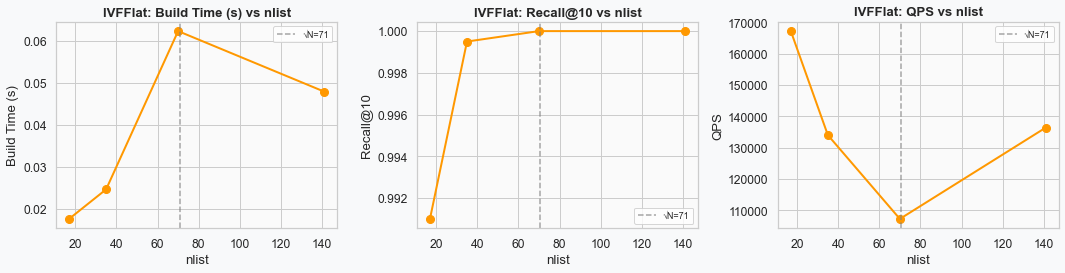

In [19]:
nlist_values = [int(np.sqrt(N)//4), int(np.sqrt(N)//2), int(np.sqrt(N)), int(np.sqrt(N)*2)]
nlist_values = sorted(set([max(4, v) for v in nlist_values]))
print(f"Testing nlist values: {nlist_values}  (sqrt(N) ≈ {np.sqrt(N):.0f})\n")

nlist_results = []
for nlist in tqdm(nlist_values, desc="nlist"):
    quantizer = faiss.IndexFlatIP(DIM)
    idx = faiss.IndexIVFFlat(quantizer, DIM, nlist, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    idx.train(corpus_vectors)
    idx.add(corpus_vectors)
    bt = time.perf_counter() - t0
    idx.nprobe = max(1, nlist // 10)  # nprobe = 10% of nlist
    _, I_sweep, t_q = run_queries(idx, query_vectors, TOP_K)
    rec = recall_at_k(flat_I, I_sweep)
    qps = N_QUERIES / t_q
    nlist_results.append({"nlist": nlist, "build_s": bt, "recall": rec, "qps": qps, "nprobe": idx.nprobe})
    print(f"  nlist={nlist:<5} nprobe={idx.nprobe:<3} build={bt:.2f}s  recall={rec:.4f}  QPS={qps:.1f}")

df_nlist = pd.DataFrame(nlist_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#F8F9FA')
for ax, metric, label in zip(axes,
                               ['build_s', 'recall', 'qps'],
                               ['Build Time (s)', f'Recall@{TOP_K}', 'QPS']):
    ax.plot(df_nlist['nlist'], df_nlist[metric], 'o-', color=PALETTE['IVFFlat'], lw=2, ms=8)
    ax.axvline(np.sqrt(N), color='gray', linestyle='--', alpha=0.7, label=f'√N={np.sqrt(N):.0f}')
    ax.set_title(f'IVFFlat: {label} vs nlist', fontweight='bold')
    ax.set_xlabel('nlist'); ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('ivfflat_nlist_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 🧪 Cell 17 — Bonus: HNSW Parameter Sensitivity (M)

Higher `M` = more graph edges = better recall, more memory, slower build.

Testing HNSW M values: [8, 16, 32, 48]



M:   0%|          | 0/4 [00:00<?, ?it/s]

  M=8    build=0.10s  recall=1.0000  QPS=139256.4
  M=16   build=0.10s  recall=1.0000  QPS=134852.7
  M=32   build=0.09s  recall=1.0000  QPS=120040.8
  M=48   build=0.07s  recall=1.0000  QPS=148500.1


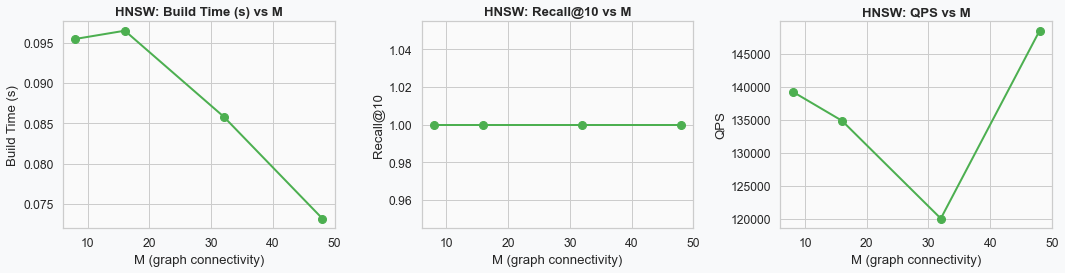

In [20]:
M_values = [8, 16, 32, 48]
print(f"Testing HNSW M values: {M_values}\n")

m_results = []
for M in tqdm(M_values, desc="M"):
    idx = faiss.IndexHNSWFlat(DIM, M, faiss.METRIC_INNER_PRODUCT)
    idx.hnsw.efConstruction = HNSW_EF_CONSTRUCTION
    t0 = time.perf_counter()
    idx.add(corpus_vectors)
    bt = time.perf_counter() - t0
    idx.hnsw.efSearch = HNSW_EF_SEARCH
    _, I_sweep, t_q = run_queries(idx, query_vectors, TOP_K)
    rec = recall_at_k(flat_I, I_sweep)
    qps = N_QUERIES / t_q
    m_results.append({"M": M, "build_s": bt, "recall": rec, "qps": qps})
    print(f"  M={M:<4} build={bt:.2f}s  recall={rec:.4f}  QPS={qps:.1f}")

df_m = pd.DataFrame(m_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#F8F9FA')
for ax, metric, label in zip(axes,
                               ['build_s', 'recall', 'qps'],
                               ['Build Time (s)', f'Recall@{TOP_K}', 'QPS']):
    ax.plot(df_m['M'], df_m[metric], 'o-', color=PALETTE['HNSW'], lw=2, ms=8)
    ax.set_title(f'HNSW: {label} vs M', fontweight='bold')
    ax.set_xlabel('M (graph connectivity)')
    ax.set_ylabel(label)
    ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('hnsw_M_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 💾 Cell 18 — Save & Load Indexes (Persistence)

FAISS lets you serialize indexes to disk — critical for production use.

In [ ]:
import os
os.makedirs("saved_indexes", exist_ok=True)

# ── Save ──────────────────────────────────────────────────────────────
faiss.write_index(index_flat, "saved_indexes/flat.index")
faiss.write_index(index_ivf,  "saved_indexes/ivfflat.index")
faiss.write_index(index_hnsw, "saved_indexes/hnsw.index")

sizes = {n: os.path.getsize(p)/1024**2
         for n, p in [("FLAT", "saved_indexes/flat.index"),
                       ("IVFFlat", "saved_indexes/ivfflat.index"),
                       ("HNSW", "saved_indexes/hnsw.index")]}
print("💾 Index file sizes on disk:")
for n, s in sizes.items():
    print(f"   {n:<10}: {s:.1f} MB")

# ── Load & Verify ─────────────────────────────────────────────────────
loaded_flat = faiss.read_index("saved_indexes/flat.index")
_, I_reload, _ = run_queries(loaded_flat, query_vectors[:5], TOP_K)
assert (I_reload == flat_I[:5]).all(), "Loaded index results differ!"
print("\n✅ Load & verify passed — FLAT index reloaded correctly.")

print("\n💡 Tip: For IVFFlat, remember to set nprobe again after loading:")
print("   loaded_ivf = faiss.read_index('ivfflat.index')")
print("   loaded_ivf.nprobe = 10")

---
## 🧭 Cell 19 — Decision Guide

Use this flowchart to decide which index to use in your own projects:

```
                    ┌─────────────────┐
                    │  How large is   │
                    │  your dataset?  │
                    └────────┬────────┘
                             │
               ┌─────────────┼─────────────┐
             < 100K        100K–5M         > 5M
               │              │              │
          ┌────▼────┐   ┌─────▼─────┐  ┌────▼────────┐
          │  FLAT   │   │  Memory   │  │  Use HNSW   │
          │ (exact) │   │constrained│  │  (sharded   │
          └─────────┘   └─────┬─────┘  │   or GPU)   │
                               │        └─────────────┘
                        ┌──────┴──────┐
                        │             │
                       YES            NO
                        │             │
                   ┌────▼────┐  ┌─────▼──────┐
                   │IVFFlat  │  │    HNSW    │
                   │(low RAM)│  │(low latency│
                   └─────────┘  │ high recall│
                                └────────────┘
```

### Parameter Quick Reference

**IVFFlat tuning:**
- Start with `nlist = sqrt(N)`, `nprobe = nlist // 10`
- Increase `nprobe` to improve recall (cap at `nlist` for FLAT-equivalent behavior)
- Increase `nlist` if your clusters are too large (query touching too many vectors)

**HNSW tuning:**
- `M = 16` → low memory, decent recall; `M = 48` → high memory, very high recall
- `efConstruction = 200` is a safe default; lower only if build time is unacceptable
- `efSearch`: start at `2*k` and increase until recall is acceptable
- Diminishing returns on recall above `efSearch = 256` for most datasets

---

## 🚀 Next Steps

1. **Try on your own data** — set `DATA_FOLDER` in Cell 2 to your documents folder
2. **Try a larger model** — swap `all-MiniLM-L6-v2` for `all-mpnet-base-v2` (768-dim) and observe how dimensionality affects results
3. **Try FAISS GPU** — install `faiss-gpu` and use `faiss.index_cpu_to_gpu()` for massive speedups
4. **Try quantization** — use `IndexIVFPQ` (Product Quantization) for even lower memory at some recall cost
5. **Try other frameworks** — Qdrant, Weaviate, Milvus, Chroma all use HNSW internally; now you understand what's happening under the hood!